In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [14]:
# read the data
data = pd.read_csv('C:\\Users\\user\\Desktop\\e-commerce-churn-analytics\\data\\rfm_features1.csv')

data.head(10)

,customer_unique_id,recency_days,frequency,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,536,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76


## EDA

 Defining Churn Target Variable

In [ ]:
median_recency = data['recency_days'].median()
print(f"The median days since last purchase is: {median_recency}")

# CHURN RULE
# if anyone has not purchased in past 365 days then considered them as churned 
# so if recency is greater than 365 then churned = 1 otherwise 0, churned is new column
# 365 days because median is 218 days meaning a customer takes almost 7 months to come back to place another order so a year would be logical to consider for churning.

data['churned'] = data['recency_days'].apply(lambda x: 1 if x > 365 else 0)

data.head(10)

The median days since last purchase is: 218.0


,customer_unique_id,recency_days,frequency,total_spent,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,0
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,0
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,0
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,166.98,0
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,35.38,0
7,00053a61a98854899e70ed204dd4bafe,182,1,419.18,0
8,0005e1862207bf6ccc02e4228effd9a0,542,1,150.12,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,129.76,0


Visualizing Class Imbalance

C:\Users\user\AppData\Local\Temp\ipykernel_3680\3937686724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='churned', palette=['#2ecc71', '#e74c3c'])


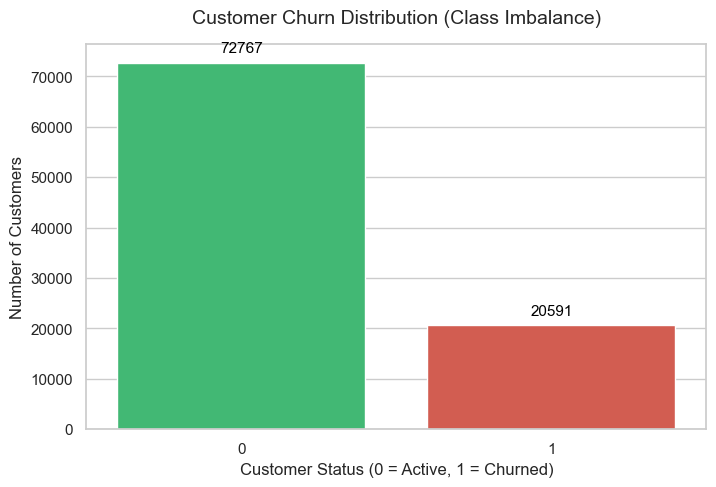

In [16]:
# Set up a grid style for our charts
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(8, 5))

# Plot the count of Active (0) vs Churned (1) customers
ax = sns.countplot(data=data, x='churned', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution (Class Imbalance)', fontsize=14, pad=15)
plt.xlabel('Customer Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Show the exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()


In [17]:
data['churned'].value_counts()

churned
0    72767
1    20591
Name: count, dtype: int64

Behvaiour Correlationals

C:\Users\user\AppData\Local\Temp\ipykernel_3680\1504751846.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='churned', y='total_spent', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


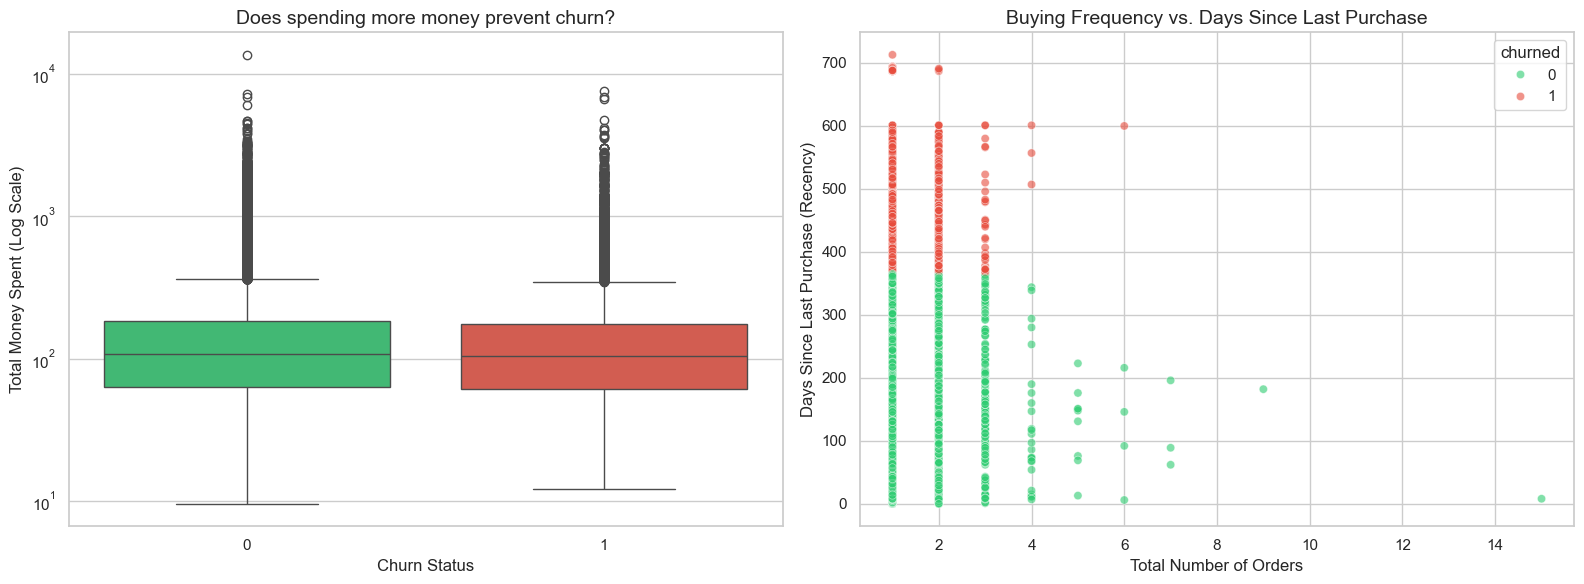

In [18]:
# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Monetary Value vs. Churn (Boxplot) ---
# We use a log scale because e-commerce money data has massive outliers 
# (e.g., one person spending $10k while most spend $50)
sns.boxplot(data=data, x='churned', y='total_spent', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_yscale('log') 
axes[0].set_title('Does spending more money prevent churn?', fontsize=14)
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Total Money Spent (Log Scale)', fontsize=12)

# --- Chart 2: Frequency vs. Recency (Scatterplot) ---
# We add jitter (transparency) so overlapping points are easier to see
sns.scatterplot(data=data, x='frequency', y='recency_days', 
                hue='churned', palette=['#2ecc71', '#e74c3c'], 
                alpha=0.6, ax=axes[1])
axes[1].set_title('Buying Frequency vs. Days Since Last Purchase', fontsize=14)
axes[1].set_xlabel('Total Number of Orders', fontsize=12)
axes[1].set_ylabel('Days Since Last Purchase (Recency)', fontsize=12)

# Tidy up the layout and display
plt.tight_layout()
plt.show()